In [74]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import ttest_rel

In [75]:
load_dotenv(override=True)

basic_folder_path = os.getenv("BASIC_FOLDER")

expert_df = pd.read_excel(os.getenv("EXPERT_CLEANED_FILE"))
anthropic_df = pd.read_excel(basic_folder_path+'/nutria_anthropic.xlsx')
gemini_df = pd.read_excel(basic_folder_path+'/nutria_gemini.xlsx')
gpt_df = pd.read_excel(basic_folder_path+'/nutria_gpt.xlsx')

In [76]:
expert_df.columns, anthropic_df.columns, gemini_df.columns, gpt_df.columns

(Index(['id', 'description', 'calories', 'proteins', 'carbohydrates', 'fats',
        'serving_size', 'observaciones'],
       dtype='object'),
 Index(['id', 'description', 'serving_size', 'calories', 'proteins',
        'carbohydrates', 'fats'],
       dtype='object'),
 Index(['id', 'description', 'serving_size', 'calories', 'proteins',
        'carbohydrates', 'fats'],
       dtype='object'),
 Index(['id', 'description', 'serving_size', 'calories', 'proteins',
        'carbohydrates', 'fats'],
       dtype='object'))

In [77]:
expert_df = expert_df.rename(columns={'description': 'expert_description', 'serving_size': 'expert_serving_size', 'calories': 'expert_calories', 'proteins': 'expert_proteins', 'carbohydrates': 'expert_carbohydrates', 'fats': 'expert_fats', 'observaciones': 'observations'})
anthropic_df = anthropic_df.rename(columns={'description': 'anthropic_description', 'serving_size': 'anthropic_serving_size', 'calories': 'anthropic_calories', 'proteins': 'anthropic_proteins', 'carbohydrates': 'anthropic_carbohydrates', 'fats': 'anthropic_fats'})
gemini_df = gemini_df.rename(columns={'description': 'gemini_description', 'serving_size': 'gemini_serving_size', 'calories': 'gemini_calories', 'proteins': 'gemini_proteins', 'carbohydrates': 'gemini_carbohydrates', 'fats': 'gemini_fats'})
gpt_df = gpt_df.rename(columns={'description': 'gpt_description', 'serving_size': 'gpt_serving_size', 'calories': 'gpt_calories', 'proteins': 'gpt_proteins', 'carbohydrates': 'gpt_carbohydrates', 'fats': 'gpt_fats'})

In [78]:
df = pd.merge(expert_df, gemini_df, on='id')
df = pd.merge(df, gpt_df, on='id')
df = pd.merge(df, anthropic_df, on='id')
df.shape

(48, 26)

In [79]:
df.head(5)

,id,expert_description,expert_calories,expert_proteins,expert_carbohydrates,expert_fats,expert_serving_size,observations,gemini_description,gemini_serving_size,...,gpt_calories,gpt_proteins,gpt_carbohydrates,gpt_fats,anthropic_description,anthropic_serving_size,anthropic_calories,anthropic_proteins,anthropic_carbohydrates,anthropic_fats
0,1,"Malta, Agua, Lúpulo, Levadura",185.00,1.90,22.5,0.00,353,NaN,Vaso de cerveza clara.,330,...,135,1.5,11.0,0.0,Cerveza clara en vaso alto con espuma,500,215.0,1.5,18.0,0.0
1,2,"Aceituna, Ajo, Pasta, Oregano, Aceite de oliva...",274.75,4.99,49.1,7.80,268,NaN,Pasta penne con salsa de tomate y albahaca,250,...,375,12.5,75.0,2.5,"Pasta penne con salsa de tomate, vegetales y h...",280,312.0,11.2,58.8,4.9
2,3,"Tomate, Salmón, Huevo, Croasant",514.00,32.40,33.0,27.40,340,NaN,El plato contiene un croissant integral con se...,250,...,450,22.0,35.0,25.0,"Pollo empanizado con semillas de sésamo, huevo...",280,520.0,38.5,8.2,36.8
3,4,"Papas fritas, Aceite de oliva, Carne de res, S...",547.00,24.30,65.0,31.00,223,NaN,Dos rebanadas de lomo de cerdo envuelto en toc...,350,...,720,38.0,40.0,48.0,Carne asada en lonchas con salsa marrón y papa...,280,520.0,35.0,28.0,30.0
4,5,"Remolacha, Arroz, Carne de res",371.50,25.30,40.3,12.05,340,NaN,"El plato contiene arroz blanco, un salteado de...",400,...,420,28.0,50.0,8.0,"Arroz blanco con guiso de carne y verduras, ac...",280,420.0,18.0,65.0,8.5


In [80]:
df.describe()

,id,expert_calories,expert_proteins,expert_carbohydrates,expert_fats,expert_serving_size,gemini_serving_size,gemini_calories,gemini_proteins,gemini_carbohydrates,...,gpt_serving_size,gpt_calories,gpt_proteins,gpt_carbohydrates,gpt_fats,anthropic_serving_size,anthropic_calories,anthropic_proteins,anthropic_carbohydrates,anthropic_fats
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,24.895833,436.305000,18.285937,47.742500,13.031979,244.62500,253.875000,307.500000,16.075000,30.487500,...,232.916667,326.354167,18.997917,28.595833,13.243750,244.062500,323.604167,16.114583,27.654167,15.766667
std,14.566414,773.030554,28.848272,126.295581,18.149397,286.10522,128.883689,230.819447,15.562865,25.567255,...,114.184590,229.646026,18.134269,24.332283,13.197951,120.533637,240.864444,14.341993,25.743332,14.526137
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,28.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.750000,49.125000,0.065000,0.425000,0.000000,97.50000,150.000000,136.250000,2.000000,5.750000,...,150.000000,125.000000,2.250000,5.750000,0.575000,150.000000,124.125000,1.950000,4.100000,0.475000
50%,24.500000,217.000000,6.555000,14.530000,5.435000,165.00000,250.000000,230.000000,10.000000,29.000000,...,250.000000,320.000000,13.300000,26.000000,8.000000,272.500000,275.000000,12.500000,23.500000,15.800000
75%,36.250000,412.725000,21.221250,40.425000,16.247500,325.00000,350.000000,550.000000,28.500000,50.000000,...,327.500000,450.000000,38.000000,45.000000,22.000000,281.250000,485.000000,28.500000,42.750000,26.500000
max,50.000000,3706.800000,123.460000,816.580000,75.040000,1670.00000,500.000000,700.000000,50.000000,90.000000,...,450.000000,720.000000,70.000000,90.000000,48.000000,500.000000,892.000000,45.000000,85.000000,45.800000


In [81]:
df = df[df['expert_serving_size']!=0]
df = df[df['id']!=31]
df = df[df['id']!=28]
df.shape

(39, 26)

In [82]:
df.describe()

,id,expert_calories,expert_proteins,expert_carbohydrates,expert_fats,expert_serving_size,gemini_serving_size,gemini_calories,gemini_proteins,gemini_carbohydrates,...,gpt_serving_size,gpt_calories,gpt_proteins,gpt_carbohydrates,gpt_fats,anthropic_serving_size,anthropic_calories,anthropic_proteins,anthropic_carbohydrates,anthropic_fats
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,...,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,22.102564,382.398718,18.266795,29.392051,13.791154,234.871795,245.794872,289.743590,15.117949,25.958974,...,221.794872,311.282051,17.574359,25.400000,13.620513,234.102564,301.666667,15.015385,23.787179,15.507692
std,13.825596,570.944329,27.379175,36.455152,16.563574,157.910564,133.105455,229.533018,15.712430,24.785774,...,116.118628,234.812461,18.408032,24.361434,13.851015,120.464407,224.963516,14.318603,23.087809,14.850631
min,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000,28.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.500000,105.900000,1.480000,2.545000,0.190000,100.000000,150.000000,112.500000,1.500000,4.000000,...,150.000000,122.500000,1.500000,4.000000,0.300000,150.000000,123.250000,1.400000,3.800000,0.350000
50%,21.000000,242.000000,10.830000,17.010000,8.630000,205.000000,250.000000,210.000000,10.000000,20.000000,...,250.000000,320.000000,12.500000,20.000000,8.000000,250.000000,265.000000,12.000000,18.000000,15.800000
75%,32.500000,417.490000,21.372500,40.550000,24.745000,330.000000,350.000000,500.000000,24.000000,45.000000,...,300.000000,420.000000,29.000000,40.000000,23.500000,280.000000,435.000000,28.500000,35.000000,26.000000
max,48.000000,3311.000000,123.460000,156.860000,58.560000,700.000000,500.000000,700.000000,50.000000,90.000000,...,450.000000,720.000000,70.000000,90.000000,48.000000,500.000000,892.000000,45.000000,78.200000,45.800000


In [83]:
metrics = ['serving_size', 'calories', 'proteins', 'carbohydrates', 'fats']
all_results = []

# true results vs predictions for each model
true_suffix = 'expert_'
pred_suffixes = ['gemini_', 'gpt_', 'anthropic_']

In [84]:
def evaluate_models(df, metrics, true_suffix='expert_', pred_suffixes=['gemini_', 'gpt_', 'anthropic_']):
    all_results = []

    for pred_suffix in pred_suffixes:
        for metric in metrics:
            y_true = df[f"{true_suffix}{metric}"]
            y_pred = df[f"{pred_suffix}{metric}"]

            mae = mean_absolute_error(y_true, y_pred)
            mask = y_true > 1e-3
            mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100 if mask.sum() > 0 else np.nan
            rmse = root_mean_squared_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)
            within_20pct = np.mean(np.abs(y_true - y_pred) / y_true <= 0.20) * 100
            t_stat, p_value = ttest_rel(y_true, y_pred)

            all_results.append({
                "Model": pred_suffix.strip('_').upper(),
                "Metric": metric.capitalize(),
                "MAE": round(mae, 2),
                "MAPE (%)": round(mape, 2) if not np.isnan(mape) else "N/A",
                "RMSE": round(rmse, 2),
                "R2 Score": round(r2, 3),
                "Within ±20%": round(within_20pct, 2),
                "T-test p-value": round(p_value, 4)
            })

    return pd.DataFrame(all_results)

In [85]:
def rank_models(result_df):
    higher_better = {
        "MAE": False,
        "MAPE (%)": False,
        "RMSE": False,
        "R2 Score": True,
        "Within ±20%": True
    }

    score_df = result_df.copy()

    for metric, high in higher_better.items():
        vals = pd.to_numeric(score_df[metric], errors='coerce')
        norm = (vals - vals.min()) / (vals.max() - vals.min())
        if not high:
            norm = 1 - norm
        score_df[f"{metric}_score"] = norm

    score_columns = [col for col in score_df.columns if col.endswith('_score')]
    model_avg_scores = score_df.groupby("Model")[score_columns].mean()
    model_avg_scores["Average Score"] = model_avg_scores.mean(axis=1)
    model_avg_scores["Rank"] = model_avg_scores["Average Score"].rank(ascending=False)

    return model_avg_scores.sort_values("Rank").reset_index()


In [86]:
def plot_heatmap(df, metric_cols):
    df_norm = df.copy()
    df_norm[metric_cols] = df_norm[metric_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

    for metric in metric_cols:
        plt.figure(figsize=(6, 4))
        sns.heatmap(
            df_norm.pivot(index="Metric", columns="Model", values=metric),
            annot=True,
            cmap="RdYlGn",  # red-yellow-green colormap
            cbar=True,
            fmt=".2f",
            linewidths=0.5,
            linecolor='gray'
        )
        plt.title(f"Heatmap of {metric} (Normalized)")
        plt.tight_layout()
        plt.show()


In [87]:
def plot_bar_comparison(df, metric_name):
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x="Metric", y=metric_name, hue="Model")
    plt.title(f"{metric_name} Comparison Across Models")
    plt.ylabel(metric_name)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [88]:
from cmath import pi

def plot_radar_per_metric(df, metrics):
    categories = list(df["Metric"].unique())

    for metric in metrics:
        values_dict = {}
        for model in df["Model"].unique():
            values = df[df["Model"] == model][metric].astype(float).values
            values = (values - np.min(values)) / (np.max(values) - np.min(values))  # Normalize
            values_dict[model] = np.concatenate((values, [values[0]]))  # Close the radar chart

        angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        for model, values in values_dict.items():
            ax.plot(angles, values, label=model)
            ax.fill(angles, values, alpha=0.1)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories)
        ax.set_title(f"Radar Chart for {metric} (Normalized)")
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
        plt.tight_layout()
        plt.show()


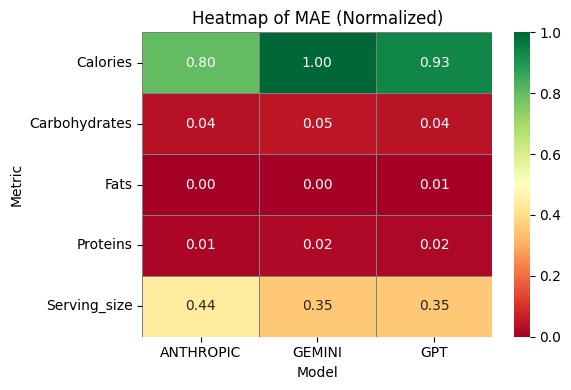

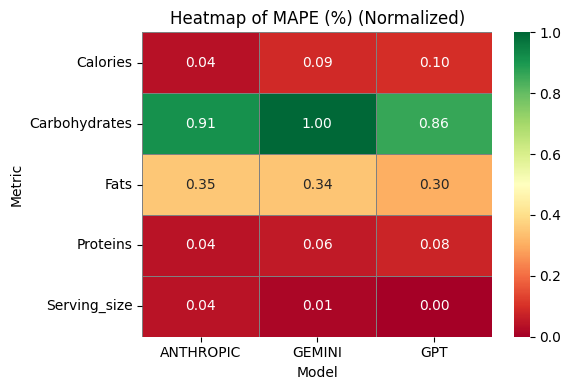

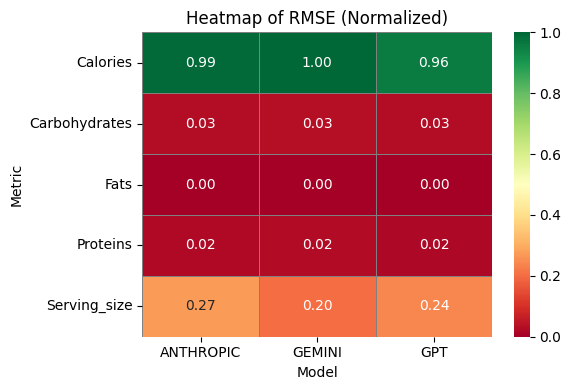

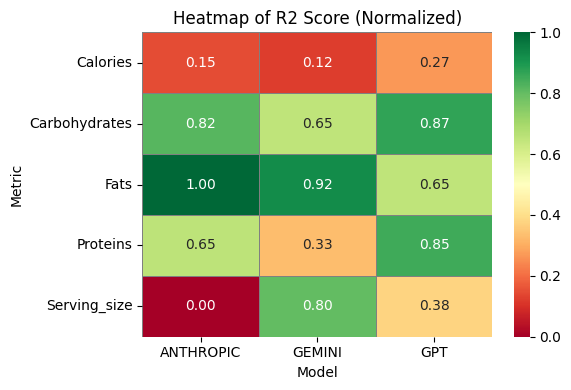

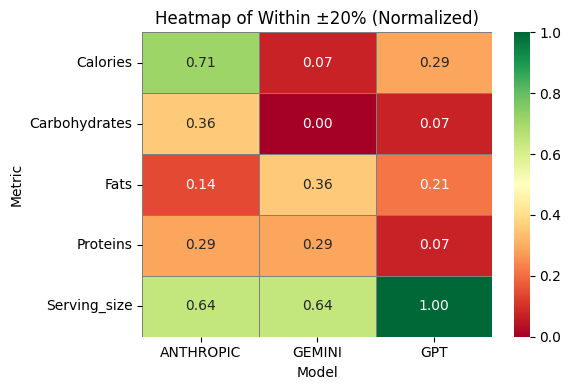

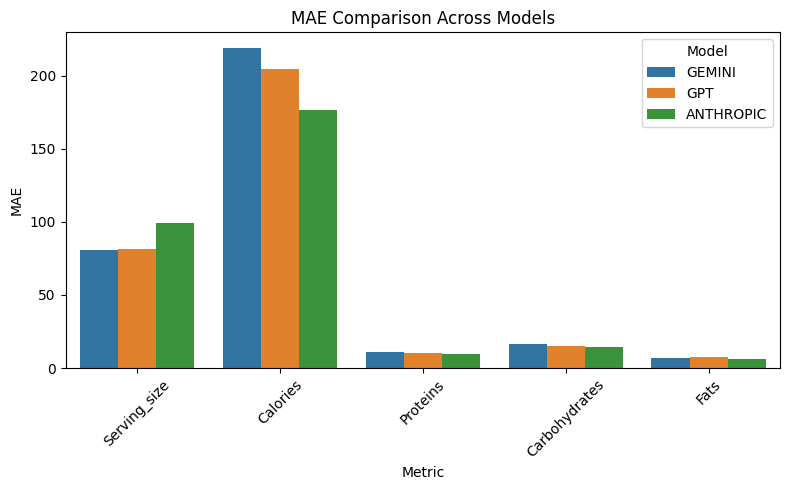

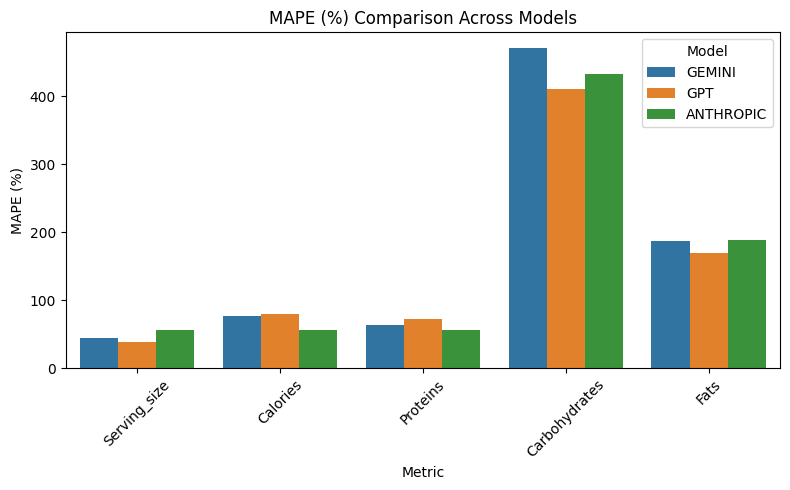

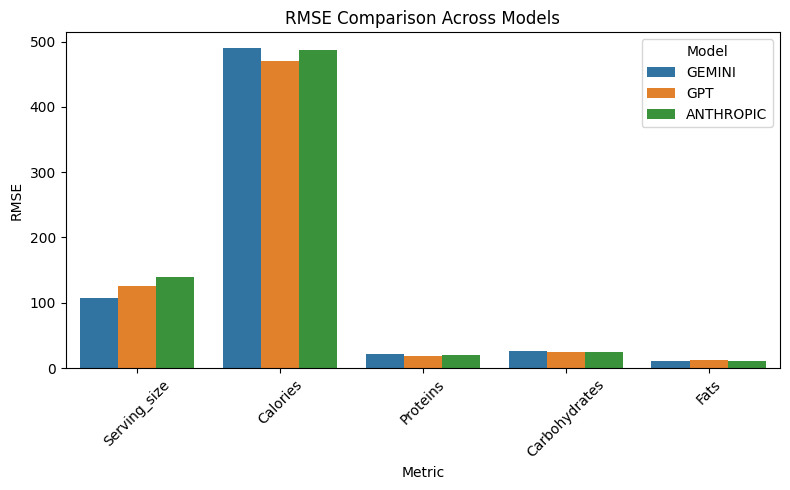

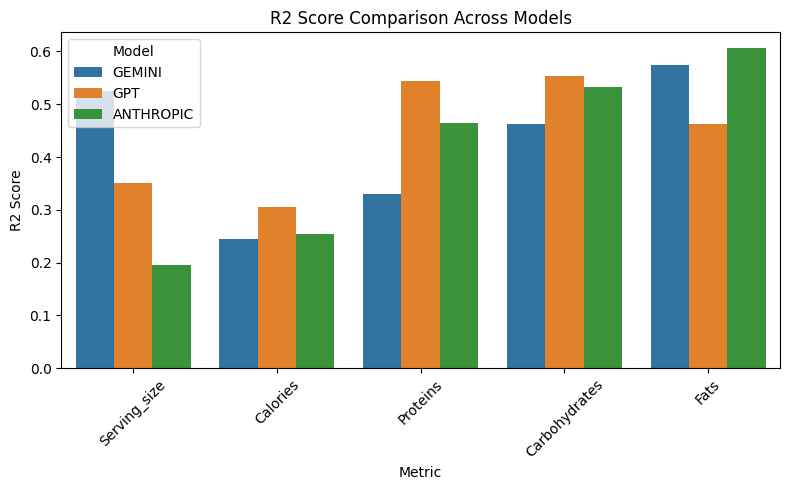

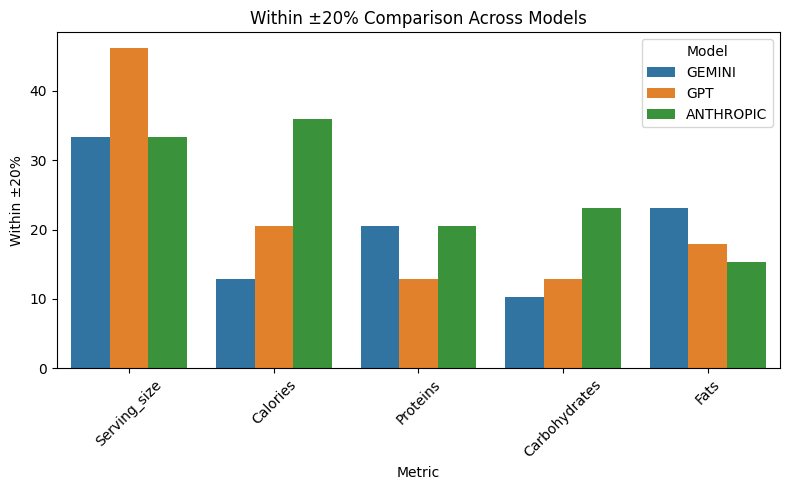

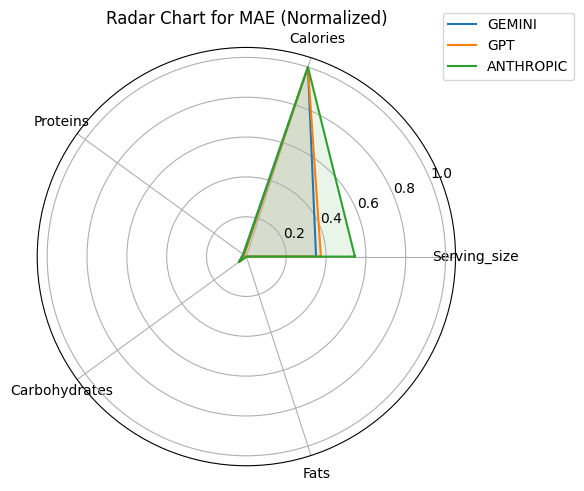

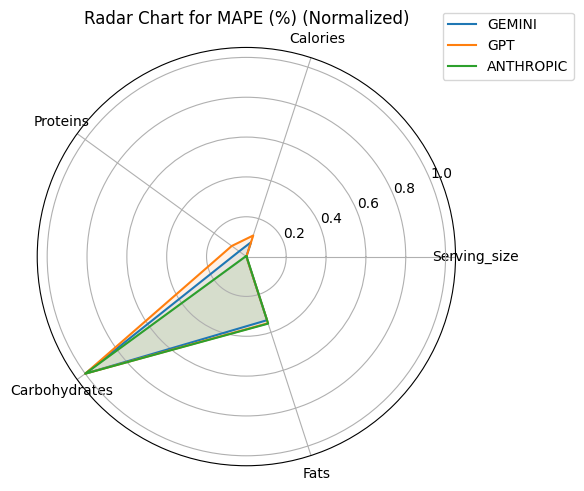

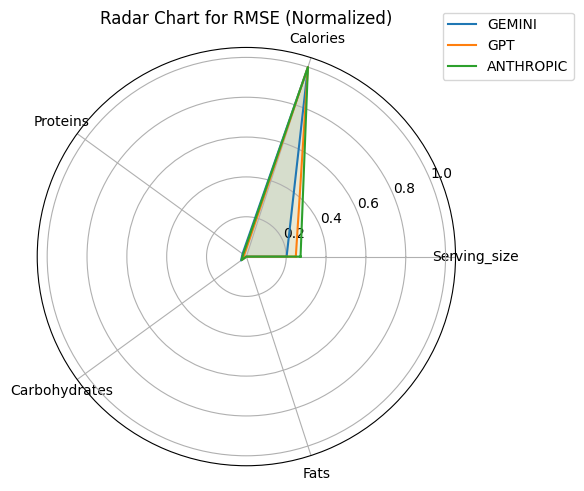

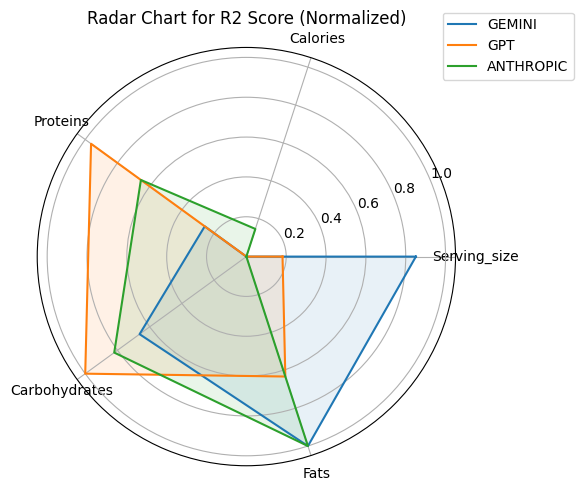

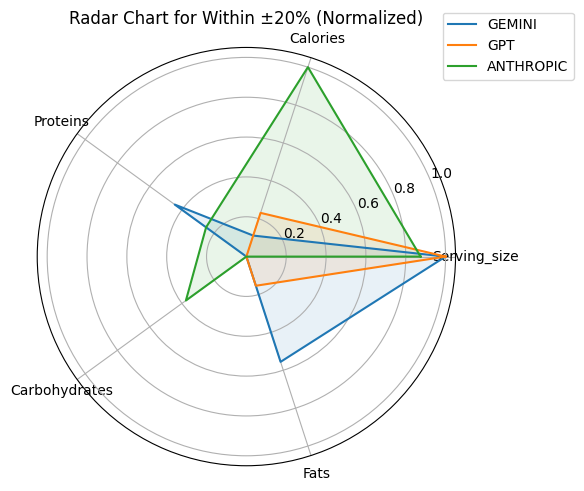

,Model,MAE_score,MAPE (%)_score,RMSE_score,R2 Score_score,Within ±20%_score,Average Score,Rank
0,ANTHROPIC,0.741642,0.723902,0.737250,0.524088,0.428532,0.631083,1.0
1,GPT,0.729946,0.732399,0.750275,0.602920,0.328504,0.628809,2.0
2,GEMINI,0.714888,0.699206,0.747609,0.565450,0.271385,0.599708,3.0


In [90]:
metrics = ['serving_size', 'calories', 'proteins', 'carbohydrates', 'fats']
results_df = evaluate_models(df, metrics)
ranking_df = rank_models(results_df)

# Visualize
metric_columns = ["MAE", "MAPE (%)", "RMSE", "R2 Score", "Within ±20%"]
plot_heatmap(results_df, metric_columns)

for metric in metric_columns:
    plot_bar_comparison(results_df, metric)

plot_radar_per_metric(results_df, metric_columns)

# Show final ranking
ranking_df
